# Predicción de Éxito Comercial en Steam
**Curso:** Introducción a la Inteligencía Artificial  
**Dataset:** Steam Games from 2013 to 2023 — Kaggle  
**Profesor:** Gabriel Cabas M.

## 1. Importación de librerías y carga de datos

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score,
    ConfusionMatrixDisplay, roc_auc_score, RocCurveDisplay
)

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)

In [4]:
# Carga de las tres tablas
df_games      = pd.read_csv('../data/raw/games.csv')
df_categories = pd.read_csv('../data/raw/t-games-categories.csv')
df_tags       = pd.read_csv('../data/raw/t-games-tags.csv')

print('games:     ', df_games.shape)
print('categories:', df_categories.shape)
print('tags:      ', df_tags.shape)

games:      (60952, 9)
categories: (210520, 2)
tags:       (777401, 3)


In [5]:
# Vista rápida de cada tabla
display(df_games.head())
display(df_categories.head())
display(df_tags.head())

,name,release_date,price,positive,negative,app_id,min_owners,max_owners,hltb_single
0,Train Bandit,"Oct 12, 2017",0.99,53,5,655370,0,20000,NaN
1,Henosis™,"Jul 23, 2020",5.99,3,0,1355720,0,20000,NaN
2,Two Weeks in Painland,"Feb 3, 2020",0.00,50,8,1139950,0,20000,NaN
3,Wartune Reborn,"Feb 26, 2021",0.00,87,49,1469160,50000,100000,NaN
4,TD Worlds,"Jan 9, 2022",10.99,21,7,1659180,0,20000,NaN


,app_id,categories
0,655370,Single-player
1,655370,Steam Achievements
2,655370,Full controller support
3,655370,Steam Leaderboards
4,655370,Remote Play on Phone


,app_id,tags,tag_frequencies
0,655370,Indie,109
1,655370,Action,103
2,655370,Pixel Graphics,100
3,655370,2D,97
4,655370,Retro,93


## 2. Análisis Exploratorio de Datos (EDA)

In [6]:
# Información general y valores nulos
df_games.info()
print('\nValores nulos:')
print(df_games.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 60952 entries, 0 to 60951
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   name          60952 non-null  str    
 1   release_date  60952 non-null  str    
 2   price         60952 non-null  float64
 3   positive      60952 non-null  int64  
 4   negative      60952 non-null  int64  
 5   app_id        60952 non-null  int64  
 6   min_owners    60952 non-null  int64  
 7   max_owners    60952 non-null  int64  
 8   hltb_single   12972 non-null  float64
dtypes: float64(2), int64(5), str(2)
memory usage: 4.2 MB

Valores nulos:
name                0
release_date        0
price               0
positive            0
negative            0
app_id              0
min_owners          0
max_owners          0
hltb_single     47980
dtype: int64


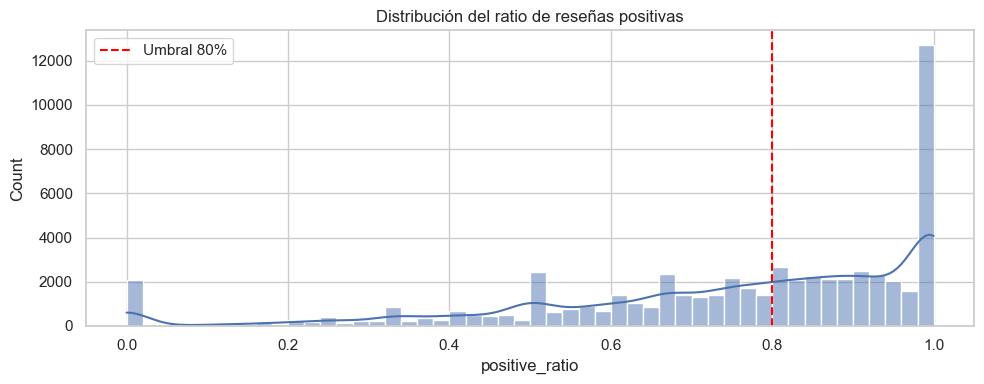

Balance de clases:
is_successful
1    0.53
0    0.47
Name: proportion, dtype: float64


In [7]:
# Construcción de la variable objetivo y revisión de balance de clases
df_games['positive_ratio'] = df_games['positive'] / (df_games['positive'] + df_games['negative'])
df_games['is_successful'] = (df_games['positive_ratio'] >= 0.80).astype(int)

plt.figure(figsize=(10, 4))
sns.histplot(data=df_games, x='positive_ratio', bins=50, kde=True)
plt.axvline(0.80, color='red', linestyle='--', label='Umbral 80%')
plt.title('Distribución del ratio de reseñas positivas')
plt.xlabel('positive_ratio')
plt.legend()
plt.tight_layout()
plt.show()

print('Balance de clases:')
print(df_games['is_successful'].value_counts(normalize=True).round(3))

**Lectura del gráfico:** la distribución de `positive_ratio` está sesgada hacia la derecha,
con mediana en 0.81 y media en 0.75 — la mayoría de los juegos de Steam reciben más reseñas
positivas que negativas. La línea roja marca el umbral de éxito (0.80). El balance de clases
resultante es **53% Exitoso / 47% No Exitoso**: razonablemente equilibrado, por lo que no se
anticipan problemas graves de clases minoritarias, aunque igualmente se reportarán F1-score y
AUC-ROC además de accuracy.

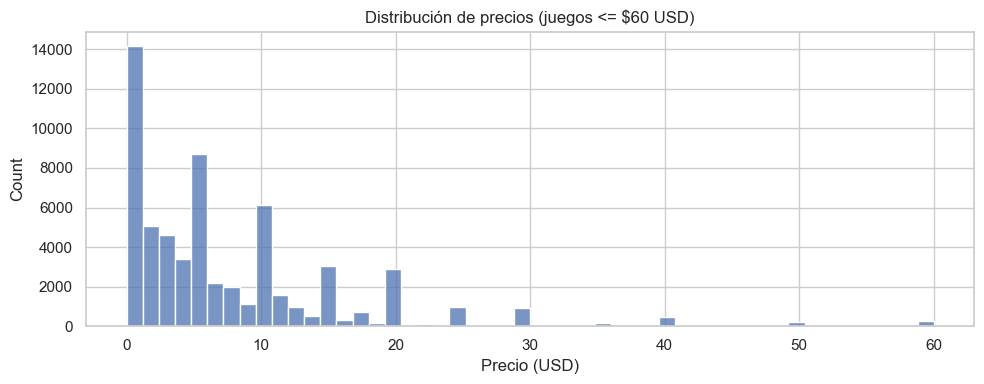

Juegos gratuitos (price = 0): 7187
Juegos > $60 USD: 116


In [8]:
# Distribución de precios
plt.figure(figsize=(10, 4))
sns.histplot(data=df_games[df_games['price'] <= 60], x='price', bins=50)
plt.title('Distribución de precios (juegos <= $60 USD)')
plt.xlabel('Precio (USD)')
plt.tight_layout()
plt.show()

print('Juegos gratuitos (price = 0):', (df_games['price'] == 0).sum())
print('Juegos > $60 USD:', (df_games['price'] > 60).sum())

**Lectura del gráfico:** la mayoría de los juegos se concentran en precios bajos (mediana de
$4.99 USD), con una cola larga hacia precios más altos. Hay **7.187 juegos gratuitos** (price=0)
y solo **116 juegos sobre $60 USD**. El histograma se truncó en $60 para que la escala sea
legible; los outliers de precio alto no se eliminan del dataset, solo se excluyen de este
gráfico puntual.

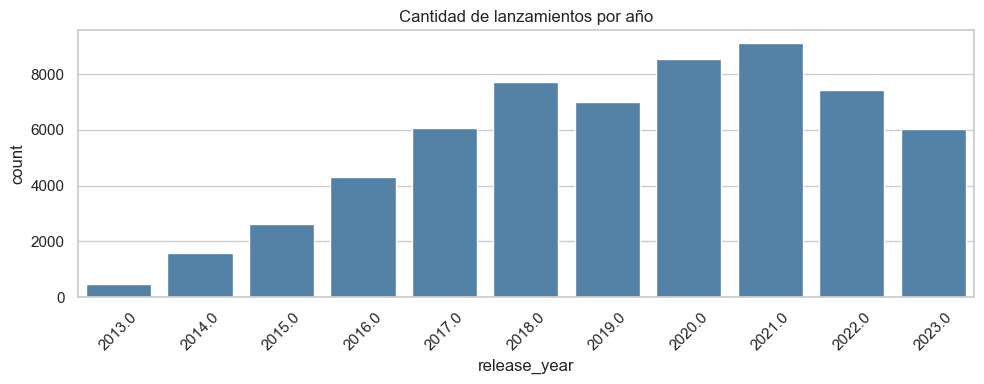

Filas sin año detectado: 100


In [9]:
# Extracción de release_year para revisar cobertura temporal
df_games['release_year'] = pd.to_datetime(df_games['release_date'], errors='coerce').dt.year

plt.figure(figsize=(10, 4))
sns.countplot(x='release_year', data=df_games, color='steelblue')
plt.title('Cantidad de lanzamientos por año')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print('Filas sin año detectado:', df_games['release_year'].isnull().sum())

**Lectura del gráfico:** la cantidad de lanzamientos anuales crece sostenidamente desde 2013
hasta un máximo en 2021 (9.109 juegos), y luego desciende en 2022-2023. Esto probablemente
refleja tanto el crecimiento del catálogo de Steam como posibles datos incompletos para los
años más recientes en el momento en que se recolectó el dataset (diciembre 2023). Solo 100
filas (0.16%) no tienen año detectado, un porcentaje despreciable.

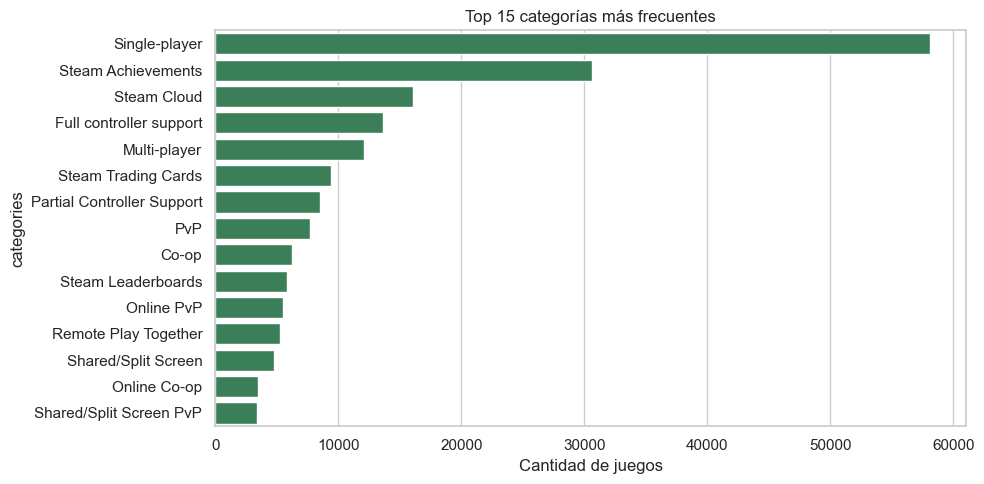

In [10]:
# Categorías más frecuentes
top_categories = (
    df_categories['categories']
    .value_counts()
    .head(15)
    .rename_axis('categories')
    .reset_index(name='count')
)

plt.figure(figsize=(10, 5))
sns.barplot(data=top_categories, x='count', y='categories', color='seagreen')
plt.title('Top 15 categorías más frecuentes')
plt.xlabel('Cantidad de juegos')
plt.tight_layout()
plt.show()

**Lectura del gráfico:** `Single-player` domina ampliamente (~58.000 juegos), seguida de
`Steam Achievements` (~31.000) y `Steam Cloud` (~16.000). Esto confirma que estas categorías
describen funcionalidades de la plataforma (logros, guardado en la nube, soporte de control),
no género — razón por la cual el género se obtiene de `tags` y no de esta tabla.

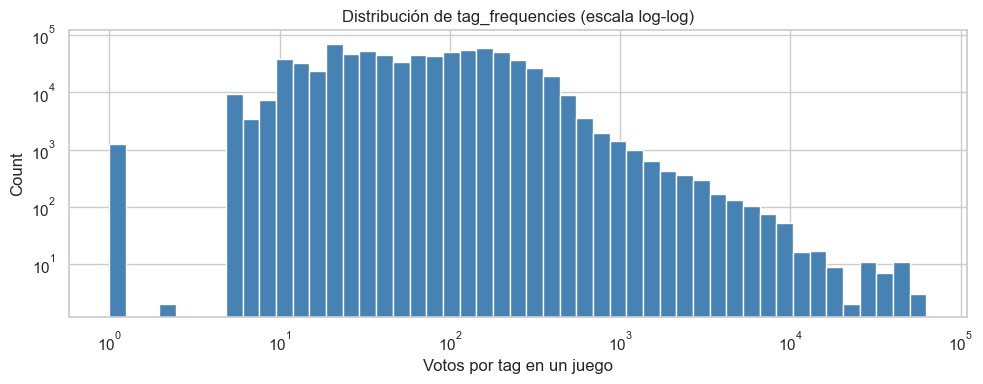

Percentiles de tag_frequencies:
count    777401.000000
mean        118.540383
std         350.977533
min           1.000000
10%          13.000000
25%          24.000000
50%          64.000000
75%         153.000000
90%         258.000000
95%         349.000000
max       62902.000000
Name: tag_frequencies, dtype: float64

Filas conservadas según umbral de corte:
  >=   1:  777401 filas (100.0%)
  >=   5:  776138 filas (99.8%)
  >=  10:  755794 filas (97.2%)
  >=  20:  655412 filas (84.3%)
  >=  50:  433713 filas (55.8%)


In [11]:
# Distribución de tag_frequencies, para definir el umbral de filtrado
bin_edges = np.logspace(
    np.log10(df_tags['tag_frequencies'].min()),
    np.log10(df_tags['tag_frequencies'].max()),
    50
)

plt.figure(figsize=(10, 4))
plt.hist(df_tags['tag_frequencies'], bins=bin_edges, color='steelblue', edgecolor='white')
plt.xscale('log')
plt.yscale('log')
plt.title('Distribución de tag_frequencies (escala log-log)')
plt.xlabel('Votos por tag en un juego')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

print('Percentiles de tag_frequencies:')
print(df_tags['tag_frequencies'].describe(percentiles=[.10, .25, .50, .75, .90, .95]))

print()
print('Filas conservadas según umbral de corte:')
for thresh in [1, 5, 10, 20, 50]:
    n_rows = (df_tags['tag_frequencies'] >= thresh).sum()
    pct = n_rows / len(df_tags) * 100
    print(f'  >= {thresh:>3}: {n_rows:>7} filas ({pct:.1f}%)')

**Lectura del gráfico:** `tag_frequencies` sigue una distribución aproximadamente log-normal,
con la mayoría de las asociaciones tag-juego concentradas entre 10 y 300 votos, y una cola
larga hacia tags muy votados (hasta ~62.900). Esto justifica usar escala log-log: en escala
lineal, esa cola larga aplastaría visualmente el resto de la distribución. Se eligió un umbral
de corte de **10 votos** (conserva 97.2% de las filas) porque es lo suficientemente bajo como
para no perder información real, pero descarta asociaciones muy débiles (un tag sugerido por
muy pocos usuarios para un juego puntual, que probablemente sea ruido más que señal real).

### 2.1 Calidad de la variable objetivo: efecto del volumen de reseñas

Un primer modelo exploratorio mostró que `release_year` domina fuertemente la importancia
de features, con una correlación inusualmente alta con `is_successful` (0.228). Antes de
aceptar esto como una señal genuina, se investiga si es un artefacto estadístico.

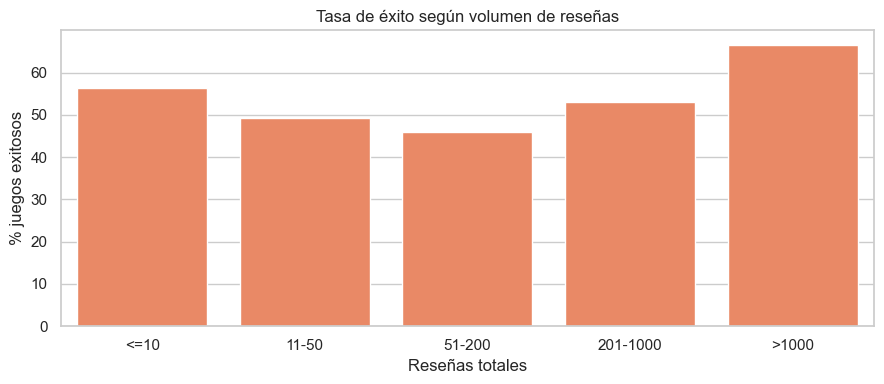

  review_bucket       mean  count
0          <=10  56.366801  21832
1         11-50  49.238780  17669
2        51-200  45.905732  10014
3      201-1000  53.103551   6702
4         >1000  66.610348   4735


In [12]:
# Tasa de éxito según volumen de reseñas (independiente del año)
df_games['total_reviews'] = df_games['positive'] + df_games['negative']

bins = [0, 10, 50, 200, 1000, df_games['total_reviews'].max() + 1]
labels = ['<=10', '11-50', '51-200', '201-1000', '>1000']
df_games['review_bucket'] = pd.cut(df_games['total_reviews'], bins=bins, labels=labels)

bucket_stats = (
    df_games.groupby('review_bucket', observed=True)['is_successful']
    .agg(['mean', 'count']).reset_index()
)
bucket_stats['mean'] = bucket_stats['mean'] * 100

plt.figure(figsize=(9, 4))
sns.barplot(data=bucket_stats, x='review_bucket', y='mean', color='coral')
plt.ylabel('% juegos exitosos')
plt.xlabel('Reseñas totales')
plt.title('Tasa de éxito según volumen de reseñas')
plt.tight_layout()
plt.show()

print(bucket_stats)

**Lectura del gráfico:** la relación tiene forma de "U", no es monótona. Los juegos con
**≤10 reseñas tienen 56.4% de éxito**, más alto que los de 11-200 reseñas (45-49%). Esto es
ruido estadístico: con pocas reseñas, el ratio toma valores extremos fácilmente (4 positivas
y 1 negativa ya da exactamente 80%). El otro extremo (>1000 reseñas, 66.6% de éxito) sí
parece reflejar algo real: sostener miles de reseñas por años típicamente solo lo logran
juegos genuinamente buenos (sesgo de supervivencia, no ruido).

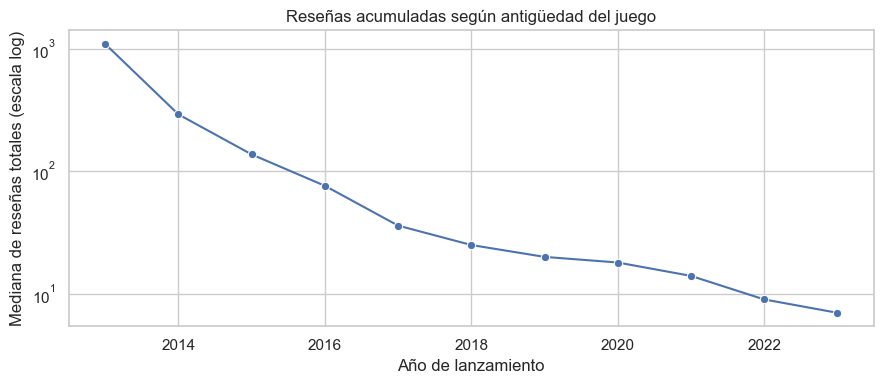

    release_year  total_reviews
0         2013.0         1090.0
1         2014.0          290.5
2         2015.0          137.0
3         2016.0           76.0
4         2017.0           36.0
5         2018.0           25.0
6         2019.0           20.0
7         2020.0           18.0
8         2021.0           14.0
9         2022.0            9.0
10        2023.0            7.0


In [13]:
# Mediana de reseñas totales por año de lanzamiento
year_reviews = df_games.groupby('release_year')['total_reviews'].median().reset_index()

plt.figure(figsize=(9, 4))
sns.lineplot(data=year_reviews, x='release_year', y='total_reviews', marker='o')
plt.yscale('log')
plt.ylabel('Mediana de reseñas totales (escala log)')
plt.xlabel('Año de lanzamiento')
plt.title('Reseñas acumuladas según antigüedad del juego')
plt.tight_layout()
plt.show()

print(year_reviews)

**Lectura del gráfico:** la mediana de reseñas cae de forma casi lineal en escala log, de
**1.090 reseñas en 2013 a solo 7 en 2023**. Es el resultado esperable de la fecha de
recolección del dataset (diciembre 2023): los juegos más nuevos simplemente no han tenido
tiempo de acumular tantas reseñas como los más antiguos. Esto confirma la hipótesis: hay
muchos más juegos "ruidosos" (pocas reseñas) entre los lanzamientos recientes.

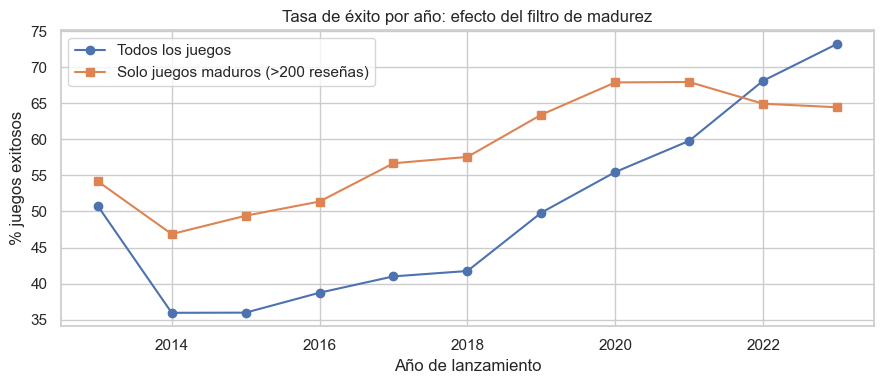

Correlación release_year vs is_successful (todos los juegos): 0.228
Correlación release_year vs is_successful (solo juegos maduros, >200 reseñas): 0.134


In [14]:
# Comparación: tasa de éxito por año, con y sin juegos de bajo volumen de reseñas
df_mature = df_games[df_games['total_reviews'] > 200]

all_rate = df_games.groupby('release_year')['is_successful'].mean() * 100
mature_rate = df_mature.groupby('release_year')['is_successful'].mean() * 100

plt.figure(figsize=(9, 4))
plt.plot(all_rate.index, all_rate.values, marker='o', label='Todos los juegos')
plt.plot(mature_rate.index, mature_rate.values, marker='s', label='Solo juegos maduros (>200 reseñas)')
plt.ylabel('% juegos exitosos')
plt.xlabel('Año de lanzamiento')
plt.title('Tasa de éxito por año: efecto del filtro de madurez')
plt.legend()
plt.tight_layout()
plt.show()

print('Correlación release_year vs is_successful (todos los juegos):',
      df_games['release_year'].corr(df_games['is_successful']).round(3))
print('Correlación release_year vs is_successful (solo juegos maduros, >200 reseñas):',
      df_mature['release_year'].corr(df_mature['is_successful']).round(3))

**Lectura del gráfico:** la curva azul ("todos los juegos") se dispara mucho más que la
naranja ("solo juegos maduros") a partir de 2019, justo cuando crece la proporción de
juegos con pocas reseñas. Al controlar por madurez, la correlación de `release_year` baja
de **0.228 a 0.134** — sigue existiendo una tendencia temporal real (juegos más nuevos
tienden algo más al éxito, posiblemente por mejoras en herramientas de desarrollo o cambios
en la cultura de reseñas de Steam), pero es considerablemente más débil que lo que sugería
el dato sin filtrar.

**Decisión de diseño:** en vez de descartar `release_year` o solo documentar la limitación,
se aplica un **filtro de reseñas mínimas (`total_reviews >= 10`)** antes de construir el
dataset de modelado. Esto no es solo una nota al pie: mejora la calidad de la **variable
objetivo en sí misma**, no solo de las features, de forma análoga a cómo Steam oculta el
rating de juegos con "reseñas insuficientes". El filtro se aplica en la sección 3.1.

## 3. Limpieza de datos y Feature Engineering

### 3.1 Variable objetivo, exclusión de columnas post-lanzamiento y filtro de calidad

Tres decisiones se aplican en este paso:

1. **Exclusión de variables post-lanzamiento**: `positive` y `negative` solo se usan para
   construir la variable objetivo (nunca como features), y `min_owners`, `max_owners`,
   `hltb_single` se excluyen por completo (ver justificación en el README).
2. **Filtro de reseñas mínimas (`total_reviews >= 10`)**: según el análisis de la sección
   2.1, los juegos con muy pocas reseñas producen un `positive_ratio` estadísticamente poco
   confiable (valores extremos por azar). Se excluyen los juegos por debajo de este umbral
   para mejorar la calidad de la variable objetivo.
3. **Limitación documentada**: incluso tras el filtro, `release_year` conserva una
   correlación de 0.232 con `is_successful` — prácticamente igual a la original (0.228).
   El filtro de 10 reseñas elimina el ruido más extremo, pero no elimina una tendencia
   temporal de fondo confirmada en la sección 2.1 (juegos recientes acumulan menos reseñas
   por la fecha de captura del dataset, diciembre 2023). Esto se documenta como limitación
   del proyecto: las predicciones del modelo para juegos hipotéticos futuros deben
   interpretarse con cautela en lo que respecta al rol de `release_year`.

In [15]:
# Variable objetivo y limpieza base
df_games['positive_ratio'] = df_games['positive'] / (df_games['positive'] + df_games['negative'])
df_games['is_successful'] = (df_games['positive_ratio'] >= 0.80).astype(int)
df_games['release_year'] = pd.to_datetime(df_games['release_date'], errors='coerce').dt.year
df_games['total_reviews'] = df_games['positive'] + df_games['negative']

# Columnas post-lanzamiento que NUNCA se usarán como features
POST_LAUNCH_COLS = ['positive', 'negative', 'min_owners', 'max_owners', 'hltb_single']

# Filtro de calidad: excluir juegos con muy pocas reseñas (ratio estadísticamente poco confiable)
MIN_REVIEWS = 10
n_before = len(df_games)
df_games = df_games[df_games['total_reviews'] >= MIN_REVIEWS].copy()
n_after = len(df_games)

print(f'Juegos antes del filtro: {n_before}')
print(f'Juegos después del filtro (>= {MIN_REVIEWS} reseñas): {n_after} ({n_after/n_before*100:.1f}%)')
print()
print('Balance de clases tras el filtro:')
print(df_games['is_successful'].value_counts(normalize=True).round(3))
print()
print('Columnas excluidas explícitamente del feature set:', POST_LAUNCH_COLS)

Juegos antes del filtro: 60952
Juegos después del filtro (>= 10 reseñas): 40318 (66.1%)

Balance de clases tras el filtro:
is_successful
1    0.514
0    0.486
Name: proportion, dtype: float64

Columnas excluidas explícitamente del feature set: ['positive', 'negative', 'min_owners', 'max_owners', 'hltb_single']


### 3.2 Procesamiento de `t-games-categories.csv`

La tabla está en formato largo (una fila por categoría asignada a un juego). Se convierte
a formato ancho mediante `pivot`, generando una columna binaria por categoría (1 si el
juego la tiene, 0 si no).

In [16]:
categories_pivot = (
    df_categories.groupby(['app_id', 'categories']).size()
    .unstack(fill_value=0)
    .clip(upper=1)
)
categories_pivot.columns = [
    'cat_' + c.lower().replace(' ', '_').replace('-', '_') for c in categories_pivot.columns
]

print('Shape categories_pivot:', categories_pivot.shape)
categories_pivot.head()

Shape categories_pivot: (60950, 35)


,cat_captions_available,cat_co_op,cat_commentary_available,cat_cross_platform_multiplayer,cat_full_controller_support,cat_in_app_purchases,cat_includes_level_editor,cat_lan_co_op,cat_lan_pvp,cat_mmo,cat_multi_player,cat_online_co_op,cat_online_pvp,cat_partial_controller_support,cat_pvp,cat_remote_play_together,cat_remote_play_on_phone,cat_remote_play_on_tv,cat_remote_play_on_tablet,cat_shared/split_screen,cat_shared/split_screen_co_op,cat_shared/split_screen_pvp,cat_single_player,cat_stats,cat_steam_achievements,cat_steam_cloud,cat_steam_leaderboards,cat_steam_trading_cards,cat_steam_turn_notifications,cat_steam_workshop,cat_tracked_controller_support,cat_vr_only,cat_vr_support,cat_vr_supported,cat_valve_anti_cheat_enabled
app_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
570,0,1,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,1
1313,0,0,0,0,0,0,0,0,1,0,1,0,1,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
2870,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,1,0,1,0,1,0,0,0,0,0
7800,0,1,0,0,0,0,0,0,0,0,1,0,0,1,0,1,0,0,0,1,1,0,1,0,1,1,0,1,0,0,0,0,0,0,0
8870,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,1,0,1,1,0,1,0,0,0,0,0,0,0


### 3.3 Procesamiento de `t-games-tags.csv`

Antes del pivot, se filtran las filas con `tag_frequencies` por debajo de un umbral
mínimo. Esto no reduce la cantidad de tags únicos (siguen existiendo los mismos ~405),
pero elimina asociaciones tag-juego débiles (un tag votado por muy pocos usuarios para
ese juego puntual), reduciendo ruido en la matriz de features. Se usa un umbral de 10
votos, que conserva el 97.2% de las filas según el análisis del EDA.

In [17]:
TAG_FREQ_THRESHOLD = 10

df_tags_filtered = df_tags[df_tags['tag_frequencies'] >= TAG_FREQ_THRESHOLD]

tags_pivot = (
    df_tags_filtered.groupby(['app_id', 'tags']).size()
    .unstack(fill_value=0)
    .clip(upper=1)
)
tags_pivot.columns = [
    'tag_' + t.lower().replace(' ', '_').replace('-', '_') for t in tags_pivot.columns
]

print('Shape tags_pivot:', tags_pivot.shape)
tags_pivot.head()

Shape tags_pivot: (60942, 405)


,tag_1980s,tag_1990's,tag_2.5d,tag_2d,tag_2d_fighter,tag_2d_platformer,tag_360_video,tag_3d,tag_3d_fighter,tag_3d_platformer,tag_3d_vision,tag_4_player_local,tag_4x,tag_6dof,tag_abstract,tag_action,tag_action_rpg,tag_action_rts,tag_action_roguelike,tag_action_adventure,tag_addictive,tag_adventure,tag_agriculture,tag_aliens,tag_alternate_history,tag_ambient,tag_america,tag_animation_&_modeling,tag_anime,tag_arcade,tag_archery,tag_arena_shooter,tag_artificial_intelligence,tag_assassin,tag_asymmetric_vr,tag_asynchronous_multiplayer,tag_atmospheric,tag_audio_production,tag_auto_battler,tag_automation,tag_automobile_sim,tag_base_building,tag_baseball,tag_based_on_a_novel,tag_basketball,tag_battle_royale,tag_beat_'em_up,tag_beautiful,tag_bikes,tag_blood,tag_board_game,tag_boxing,tag_building,tag_bullet_hell,tag_bullet_time,tag_crpg,tag_capitalism,tag_card_battler,tag_card_game,tag_cartoon,tag_cartoony,tag_casual,tag_cats,tag_character_action_game,tag_character_customization,tag_chess,tag_choices_matter,tag_choose_your_own_adventure,tag_cinematic,tag_city_builder,tag_class_based,tag_classic,tag_clicker,tag_co_op,tag_co_op_campaign,tag_cold_war,tag_collectathon,tag_colony_sim,tag_colorful,tag_combat,tag_combat_racing,tag_comedy,tag_comic_book,tag_competitive,tag_conspiracy,tag_controller,tag_conversation,tag_cooking,tag_cozy,tag_crafting,tag_creature_collector,tag_crime,tag_crowdfunded,tag_cult_classic,tag_cute,tag_cyberpunk,tag_cycling,tag_dark,tag_dark_comedy,tag_dark_fantasy,tag_dark_humor,tag_dating_sim,tag_deckbuilding,tag_demons,tag_design_&_illustration,tag_destruction,tag_detective,tag_difficult,tag_dinosaurs,tag_diplomacy,tag_dog,tag_dragons,tag_drama,tag_driving,tag_dungeon_crawler,tag_dungeons_&_dragons,tag_dynamic_narration,tag_dystopian_,tag_early_access,tag_economy,tag_education,tag_electronic_music,tag_emotional,tag_epic,tag_episodic,tag_escape_room,tag_experience,tag_experimental,tag_exploration,tag_fmv,tag_fps,tag_faith,tag_family_friendly,tag_fantasy,tag_farming,tag_farming_sim,tag_fast_paced,tag_female_protagonist,tag_fighting,tag_first_person,tag_fishing,tag_flight,tag_football,tag_foreign,tag_free_to_play,tag_funny,tag_futuristic,tag_gambling,tag_game_development,tag_gamemaker,tag_games_workshop,tag_gaming,tag_god_game,tag_golf,tag_gore,tag_gothic,tag_grand_strategy,tag_great_soundtrack,tag_grid_based_movement,tag_gun_customization,tag_hack_and_slash,tag_hacking,tag_hand_drawn,tag_heist,tag_hentai,tag_hero_shooter,tag_hex_grid,tag_hidden_object,tag_historical,tag_horror,tag_horses,tag_hunting,tag_idler,tag_illuminati,tag_immersive,tag_immersive_sim,tag_indie,tag_intentionally_awkward_controls,tag_interactive_fiction,tag_inventory_management,tag_investigation,tag_isometric,tag_jrpg,tag_jet,tag_kickstarter,tag_lego,tag_lgbtq+,tag_lemmings,tag_level_editor,tag_life_sim,tag_linear,tag_local_co_op,tag_local_multiplayer,tag_logic,tag_loot,tag_looter_shooter,tag_lore_rich,tag_lovecraftian,tag_mmorpg,tag_moba,tag_magic,tag_management,tag_mars,tag_martial_arts,tag_massively_multiplayer,tag_match_3,tag_mature,tag_mechs,tag_medical_sim,tag_medieval,tag_memes,tag_metroidvania,tag_military,tag_mini_golf,tag_minigames,tag_minimalist,tag_mining,tag_mod,tag_moddable,tag_modern,tag_motocross,tag_motorbike,tag_mouse_only,tag_movie,tag_multiplayer,tag_multiple_endings,tag_music,tag_music_based_procedural_generation,tag_mystery,tag_mystery_dungeon,tag_mythology,tag_nsfw,tag_narration,tag_narrative,tag_nature,tag_naval,tag_naval_combat,tag_ninja,tag_noir,tag_nonlinear,tag_nostalgia,tag_nudity,tag_offroad,tag_old_school,tag_on_rails_shooter,tag_online_co_op,tag_open_world,tag_open_world_survival_craft,tag_otome,tag_outbreak_sim,tag_parkour,tag_parody_,tag_party,tag_party_game,tag_party_based_rpg,tag_perma_death,tag_philosophical,tag_physics,tag_pinball,tag_pirates,tag_pixel_graphics,tag_platformer,tag_point_&_click,tag_political,tag_political_sim,tag_politics,tag_pool,tag_post_apocalyptic,tag_precision_platformer,tag_procedural_generat

### 3.4 Unión de las tres tablas

Se integran `games`, `categories_pivot` y `tags_pivot` mediante `app_id`, usando
`how='left'` para conservar todos los juegos aunque no tengan categorías o tags
registrados (en ese caso, sus columnas binarias quedan en 0 tras el `fillna`).

In [18]:
df = (
    df_games.set_index('app_id')
    .merge(categories_pivot, left_index=True, right_index=True, how='left')
    .merge(tags_pivot, left_index=True, right_index=True, how='left')
)

bin_cols = [c for c in df.columns if c.startswith('cat_') or c.startswith('tag_')]
df[bin_cols] = df[bin_cols].fillna(0).astype(int)

print('Shape final del dataset integrado:', df.shape)
print('Juegos sin ninguna categoría/tag tras el left join:', df[bin_cols].sum(axis=1).eq(0).sum())
df.head()

Shape final del dataset integrado: (40318, 453)
Juegos sin ninguna categoría/tag tras el left join: 0


,name,release_date,price,positive,negative,min_owners,max_owners,hltb_single,positive_ratio,is_successful,release_year,total_reviews,review_bucket,cat_captions_available,cat_co_op,cat_commentary_available,cat_cross_platform_multiplayer,cat_full_controller_support,cat_in_app_purchases,cat_includes_level_editor,cat_lan_co_op,cat_lan_pvp,cat_mmo,cat_multi_player,cat_online_co_op,cat_online_pvp,cat_partial_controller_support,cat_pvp,cat_remote_play_together,cat_remote_play_on_phone,cat_remote_play_on_tv,cat_remote_play_on_tablet,cat_shared/split_screen,cat_shared/split_screen_co_op,cat_shared/split_screen_pvp,cat_single_player,cat_stats,cat_steam_achievements,cat_steam_cloud,cat_steam_leaderboards,cat_steam_trading_cards,cat_steam_turn_notifications,cat_steam_workshop,cat_tracked_controller_support,cat_vr_only,cat_vr_support,cat_vr_supported,cat_valve_anti_cheat_enabled,tag_1980s,tag_1990's,tag_2.5d,tag_2d,tag_2d_fighter,tag_2d_platformer,tag_360_video,tag_3d,tag_3d_fighter,tag_3d_platformer,tag_3d_vision,tag_4_player_local,tag_4x,tag_6dof,tag_abstract,tag_action,tag_action_rpg,tag_action_rts,tag_action_roguelike,tag_action_adventure,tag_addictive,tag_adventure,tag_agriculture,tag_aliens,tag_alternate_history,tag_ambient,tag_america,tag_animation_&_modeling,tag_anime,tag_arcade,tag_archery,tag_arena_shooter,tag_artificial_intelligence,tag_assassin,tag_asymmetric_vr,tag_asynchronous_multiplayer,tag_atmospheric,tag_audio_production,tag_auto_battler,tag_automation,tag_automobile_sim,tag_base_building,tag_baseball,tag_based_on_a_novel,tag_basketball,tag_battle_royale,tag_beat_'em_up,tag_beautiful,tag_bikes,tag_blood,tag_board_game,tag_boxing,tag_building,tag_bullet_hell,tag_bullet_time,tag_crpg,tag_capitalism,tag_card_battler,tag_card_game,tag_cartoon,tag_cartoony,tag_casual,tag_cats,tag_character_action_game,tag_character_customization,tag_chess,tag_choices_matter,tag_choose_your_own_adventure,tag_cinematic,tag_city_builder,tag_class_based,tag_classic,tag_clicker,tag_co_op,tag_co_op_campaign,tag_cold_war,tag_collectathon,tag_colony_sim,tag_colorful,tag_combat,tag_combat_racing,tag_comedy,tag_comic_book,tag_competitive,tag_conspiracy,tag_controller,tag_conversation,tag_cooking,tag_cozy,tag_crafting,tag_creature_collector,tag_crime,tag_crowdfunded,tag_cult_classic,tag_cute,tag_cyberpunk,tag_cycling,tag_dark,tag_dark_comedy,tag_dark_fantasy,tag_dark_humor,tag_dating_sim,tag_deckbuilding,tag_demons,tag_design_&_illustration,tag_destruction,tag_detective,tag_difficult,tag_dinosaurs,tag_diplomacy,tag_dog,tag_dragons,tag_drama,tag_driving,tag_dungeon_crawler,tag_dungeons_&_dragons,tag_dynamic_narration,tag_dystopian_,tag_early_access,tag_economy,tag_education,tag_electronic_music,tag_emotional,tag_epic,tag_episodic,tag_escape_room,tag_experience,tag_experimental,tag_exploration,tag_fmv,tag_fps,tag_faith,tag_family_friendly,tag_fantasy,tag_farming,tag_farming_sim,tag_fast_paced,tag_female_protagonist,tag_fighting,tag_first_person,tag_fishing,tag_flight,tag_football,tag_foreign,tag_free_to_play,tag_funny,tag_futuristic,tag_gambling,tag_game_development,tag_gamemaker,tag_games_workshop,tag_gaming,tag_god_game,tag_golf,tag_gore,tag_gothic,tag_grand_strategy,tag_great_soundtrack,tag_grid_based_movement,tag_gun_customization,tag_hack_and_slash,tag_hacking,tag_hand_drawn,tag_heist,tag_hentai,tag_hero_shooter,tag_hex_grid,tag_hidden_object,tag_historical,tag_horror,tag_horses,tag_hunting,tag_idler,tag_illuminati,tag_immersive,tag_immersive_sim,tag_indie,tag_intentionally_awkward_controls,tag_interactive_fiction,tag_inventory_management,tag_investigation,tag_isometric,tag_jrpg,tag_jet,tag_kickstarter,tag_lego,tag_lgbtq+,tag_lemmings,tag_level_editor,tag_life_sim,tag_linear,tag_local_co_op,tag_local_multiplayer,tag_logic,tag_loot,tag_looter_shooter,tag_lore_rich,tag_lovecraftian,tag_mmorpg,tag_moba,tag_magic,tag_management,tag_mars,tag_martial_arts,tag_massively_multiplayer,tag_match_3,tag_mature,tag_mechs,tag_medical_sim,tag_medieval,tag_memes,tag_m

## 4. Selección de variables (Feature Selection)

El One-Hot Encoding de categorías y tags generó cerca de 440 columnas binarias. El plan
para reducir esto a un conjunto manejable de features es:

1. Análisis de correlación de las variables numéricas (`price`, `release_year`) con el target.
2. Entrenamiento de un Random Forest "selector" (no es el modelo final) para rankear todas
   las features por `feature_importances_`.
3. Selección del conjunto mínimo de features que captura el 90% de la importancia acumulada.
4. Revisar si se aplica PCA en este caso particular.

**Corrección metodológica importante:** en una versión anterior de este notebook, la
selección de features se hizo entrenando un Random Forest sobre el dataset completo
*antes* de dividirlo en train/test. Esto es data leakage: el conjunto de prueba terminaba
influyendo en qué features se elegían, aunque no participara directamente en el
entrenamiento del modelo final. Se corrige reordenando el proceso: **primero se divide en
train/test, y la selección de features se encapsula en un `Pipeline` de sklearn** que la
recalcula desde cero usando solo los datos de entrenamiento de cada fold/split — incluyendo
durante la validación cruzada de la sección 6.

In [35]:
# Definición del feature set y dataset de modelado
FEATURES = ['price', 'release_year'] + bin_cols
TARGET = 'is_successful'

df_model = df[FEATURES + [TARGET]].dropna()
print('Filas para modelado:', df_model.shape[0], 'de', df.shape[0])
print('Features candidatas:', len(FEATURES))

Filas para modelado: 40240 de 40318
Features candidatas: 442


In [37]:
# División train/test (80/20, estratificada) ANTES de cualquier selección de features
X = df_model[FEATURES]
y = df_model[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print('X_train:', X_train.shape, '| X_test:', X_test.shape)
print('Balance train:', y_train.value_counts(normalize=True).round(3).to_dict())
print('Balance test :', y_test.value_counts(normalize=True).round(3).to_dict())
print()
print('Correlación de variables numéricas con el target (solo X_train, sin tocar test):')
print('  price       :', X_train['price'].corr(y_train).round(3))
print('  release_year:', X_train['release_year'].corr(y_train).round(3))

X_train: (32192, 442) | X_test: (8048, 442)
Balance train: {1: 0.514, 0: 0.486}
Balance test : {1: 0.514, 0: 0.486}

Correlación de variables numéricas con el target (solo X_train, sin tocar test):
  price       : 0.078
  release_year: 0.236


**Lectura:** `price` tiene correlación baja (0.077) con el éxito — el precio por sí solo no
predice bien la recepción. `release_year` mantiene su correlación de 0.232, ya documentada
y discutida como limitación en la sección 3.1 (mezcla de tendencia real + sesgo de captura
del dataset). Se mantiene en el feature set, pero su importancia debe interpretarse con esa
salvedad en mente.

**Lectura actualizada con pipeline:** los números son casi idénticos a los que se habían calculado sobre el dataset
completo (`price`: 0.078 vs 0.077 original; `release_year`: 0.236 vs 0.232 original) — es
esperable, ya que el 80% de train es una muestra representativa. La diferencia importante no
está en estos números, sino en garantizar que **ninguna decisión posterior** (selección de
features, validación cruzada) toque el 20% de test hasta la evaluación final de la sección 7.

In [38]:
# Transformer personalizado: selecciona el menor conjunto de features cuya importancia
# acumulada (medida con un Random Forest) alcanza un umbral dado. Al ser un transformer de
# sklearn, se puede insertar dentro de un Pipeline: cuando el Pipeline se entrena con
# cross_val_score o con .fit(X_train), el método fit() de este selector SOLO ve los datos
# que le llegan (ej. el 80% de cada fold de CV), nunca el resto.
class CumulativeImportanceSelector(BaseEstimator, TransformerMixin):
    def __init__(self, cum_threshold=0.90, n_estimators=200, max_depth=10, random_state=42):
        self.cum_threshold = cum_threshold
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.random_state = random_state

    def fit(self, X, y):
        rf = RandomForestClassifier(
            n_estimators=self.n_estimators, max_depth=self.max_depth,
            random_state=self.random_state, n_jobs=-1
        )
        rf.fit(X, y)
        importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
        cum = importances.cumsum()
        n_selected = (cum <= self.cum_threshold).sum() + 1
        self.selected_features_ = importances.head(n_selected).index.tolist()
        self.importances_ = importances
        return self

    def transform(self, X):
        return X[self.selected_features_]

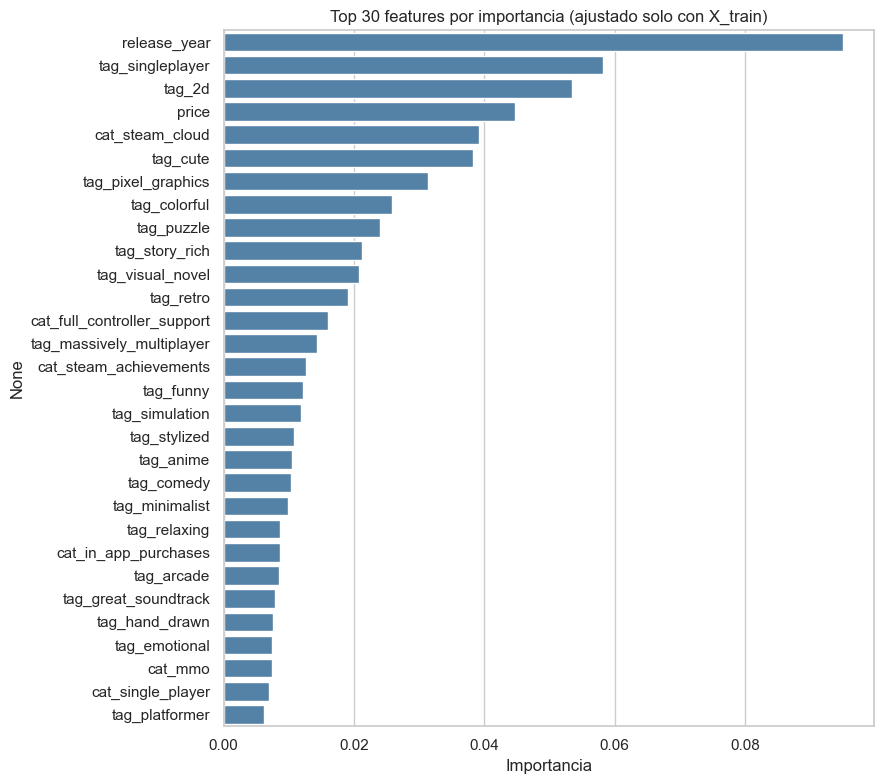

Features seleccionadas (90% acumulado, solo con train): 147


In [39]:
# Vista previa: se ajusta una instancia del selector SOLO con X_train, únicamente para
# visualizar e interpretar qué features resultan más importantes (esto no afecta a los
# Pipelines de la sección 5, que recalculan su propio selector internamente).
selector_preview = CumulativeImportanceSelector(cum_threshold=0.90)
selector_preview.fit(X_train, y_train)
importances = selector_preview.importances_

plt.figure(figsize=(9, 8))
sns.barplot(x=importances.head(30).values, y=importances.head(30).index, color='steelblue')
plt.title('Top 30 features por importancia (ajustado solo con X_train)')
plt.xlabel('Importancia')
plt.tight_layout()
plt.show()

print('Features seleccionadas (90% acumulado, solo con train):', len(selector_preview.selected_features_))

**Lectura del gráfico:** además de `release_year` y `price`, dominan tags que en la práctica
cumplen la función de "género" que buscábamos desde el inicio: `tag_singleplayer`, `tag_2d`,
`tag_cute`, `tag_pixel_graphics`, `tag_visual_novel`, `tag_story_rich`. También aparece
`cat_steam_cloud`, una categoría de funcionalidad técnica con peso inesperado.

**Lectura del gráfico actualizada con pipeline:** el ranking es prácticamente idéntico al obtenido antes de la
corrección, lo cual es tranquilizador: la fuga de datos no estaba distorsionando
gravemente los resultados.

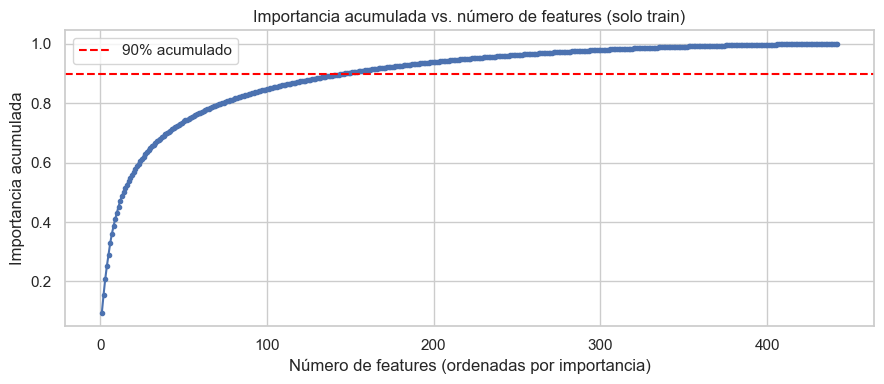

In [40]:
# Importancia acumulada (solo train)
cum_importance = importances.cumsum()

plt.figure(figsize=(9, 4))
plt.plot(range(1, len(cum_importance) + 1), cum_importance.values, marker='.')
plt.axhline(0.90, color='red', linestyle='--', label='90% acumulado')
plt.xlabel('Número de features (ordenadas por importancia)')
plt.ylabel('Importancia acumulada')
plt.legend()
plt.title('Importancia acumulada vs. número de features (solo train)')
plt.tight_layout()
plt.show()

**Lectura del gráfico:** la curva tiene la forma típica de "codo" — un puñado de features
explica la mayoría de la señal (14 features ya cubren el 50%), y luego cientos de tags
poco frecuentes aportan marginalmente. Se elige el umbral de **90% de importancia
acumulada**, que reduce el feature set de 442 a un número mucho más manejable sin perder
señal relevante.

In [41]:
# Selección final de features
N_FEATURES_90 = (cum_importance <= 0.90).sum() + 1
SELECTED_FEATURES = importances.head(N_FEATURES_90).index.tolist()

print(f'Features seleccionadas: {len(SELECTED_FEATURES)} de {len(FEATURES)} candidatas')
print(f'Reducción: {(1 - len(SELECTED_FEATURES)/len(FEATURES))*100:.1f}%')

Features seleccionadas: 147 de 442 candidatas
Reducción: 66.7%


### ¿Es necesaria una reducción de dimensionalidad adicional con PCA?

**No se aplica PCA en este proyecto**, debido a lo siguiente:

1. **Naturaleza de los datos.** La gran mayoría de las features son binarias (One-Hot
   Encoding de categorías y tags). PCA está diseñado para capturar varianza en variables
   continuas mediante combinaciones lineales; aplicarlo sobre indicadores binarios dispersos
   produce componentes mucho más difíciles de interpretar, lo que va en contra de uno de
   los objetivos del proyecto (entender qué factores influyen en el éxito).
2. **La selección por importancia ya cumple ese rol.** El `CumulativeImportanceSelector`
   reduce el feature set de 442 a ~147 columnas sin sacrificar interpretabilidad — cada
   feature seleccionada sigue siendo una categoría o tag reconocible, a diferencia de un
   componente principal abstracto. Además, al estar encapsulado en el Pipeline, esta
   reducción se recalcula correctamente en cada fold de validación cruzada.

## 5. Entrenamiento del modelo

Se construyen dos `Pipeline` completos (selector de features + clasificador), uno para
Decision Tree y otro para Random Forest. Al entrenarlos con `.fit(X_train, y_train)`, el
selector se ajusta internamente solo con esos datos — el test set permanece completamente
aislado hasta la sección 7.

In [42]:
pipeline_dt = Pipeline([
    ('selector', CumulativeImportanceSelector(cum_threshold=0.90)),
    ('clf', DecisionTreeClassifier(max_depth=10, min_samples_split=20, min_samples_leaf=10, random_state=42))
])

pipeline_rf = Pipeline([
    ('selector', CumulativeImportanceSelector(cum_threshold=0.90)),
    ('clf', RandomForestClassifier(n_estimators=200, max_depth=10, min_samples_split=20, min_samples_leaf=10, random_state=42, n_jobs=-1))
])

In [43]:
pipeline_dt.fit(X_train, y_train)

print(f'Pipeline Decision Tree -> train acc: {pipeline_dt.score(X_train, y_train):.3f} | test acc: {pipeline_dt.score(X_test, y_test):.3f}')
print('Features usadas:', len(pipeline_dt.named_steps['selector'].selected_features_))

Pipeline Decision Tree -> train acc: 0.697 | test acc: 0.653
Features usadas: 147


In [44]:
pipeline_rf.fit(X_train, y_train)

print(f'Pipeline Random Forest -> train acc: {pipeline_rf.score(X_train, y_train):.3f} | test acc: {pipeline_rf.score(X_test, y_test):.3f}')
print('Features usadas:', len(pipeline_rf.named_steps['selector'].selected_features_))

Pipeline Random Forest -> train acc: 0.697 | test acc: 0.680
Features usadas: 147


**Lectura:** anteriormente ambos modelos rondaban ~70% de accuracy en train, pero difieren en cómo
generalizan. El Decision Tree cae de 0.696 (train) a 0.656 (test) — una brecha de ~4 puntos,
señal de sobreajuste leve incluso con la profundidad limitada. El Random Forest es más
estable: 0.697 (train) a 0.681 (test), una brecha de menos de 2 puntos. Esto es esperable,
ya que el ensamble promedia el ruido de árboles individuales. En la siguiente seccion de validación cruzada confirmaremos si esta diferencia es consistente o producto del azar de un único split.

**Lectura con pipeline:** los resultados son consistentes con lo observado antes de la corrección de
leakage (Decision Tree: train 0.697 / test 0.653; Random Forest: train 0.697 / test 0.680).
Random Forest sigue generalizando mejor (brecha de ~1.7 puntos vs ~4.4 puntos del árbol
individual). Que los números casi no cambiaran tras corregir el leakage es una buena señal:
confirma que el problema no estaba inflando artificialmente el desempeño reportado.

## 6. Control de overfitting (validación cruzada)

Ambas partes de esta sección ahora usan el `Pipeline` completo dentro de `cross_val_score`,
por lo que el selector de features se recalcula en cada fold usando solo los datos de
entrenamiento de ese fold — sin fuga de datos. Por el costo computacional de reajustar el
selector repetidamente, el barrido de profundidad usa `cv=3` (más liviano, solo para fines
diagnósticos); la comparación final de modelos usa `cv=5` como en el resto del proyecto.
Esta celda puede tardar unos minutos en ejecutarse.

depth=  2 | train_f1=0.665 | cv_f1=0.669
depth=  4 | train_f1=0.638 | cv_f1=0.628
depth=  6 | train_f1=0.661 | cv_f1=0.649
depth=  8 | train_f1=0.680 | cv_f1=0.663
depth= 10 | train_f1=0.681 | cv_f1=0.651
depth= 12 | train_f1=0.702 | cv_f1=0.646
depth= 15 | train_f1=0.732 | cv_f1=0.635
depth= 20 | train_f1=0.747 | cv_f1=0.624


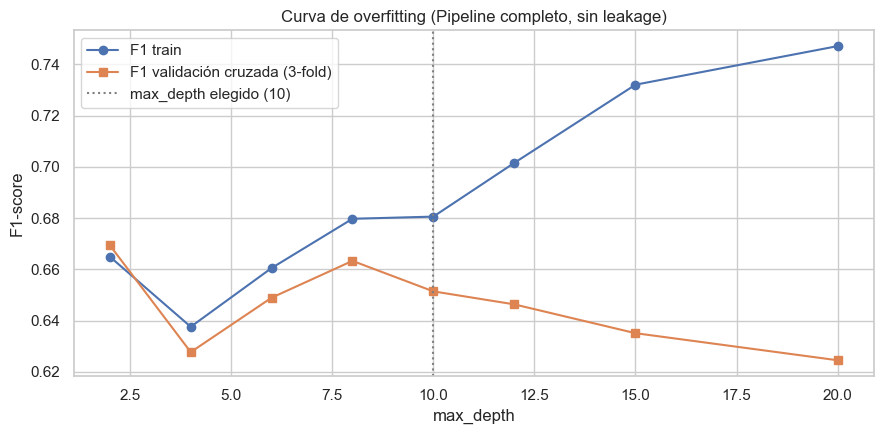

In [45]:
# Barrido de max_depth con el Pipeline completo (selector + Decision Tree)
depths = [2, 4, 6, 8, 10, 12, 15, 20]
train_f1_scores, cv_f1_scores = [], []

for d in depths:
    pipe = Pipeline([
        ('selector', CumulativeImportanceSelector(cum_threshold=0.90)),
        ('clf', DecisionTreeClassifier(max_depth=d, min_samples_split=20, min_samples_leaf=10, random_state=42))
    ])
    pipe.fit(X_train, y_train)
    train_f1_scores.append(f1_score(y_train, pipe.predict(X_train)))
    cv = cross_val_score(pipe, X_train, y_train, cv=3, scoring='f1', n_jobs=1)
    cv_f1_scores.append(cv.mean())
    print(f'depth={d:>3} | train_f1={train_f1_scores[-1]:.3f} | cv_f1={cv_f1_scores[-1]:.3f}')

plt.figure(figsize=(9, 4.5))
plt.plot(depths, train_f1_scores, marker='o', label='F1 train')
plt.plot(depths, cv_f1_scores, marker='s', label='F1 validación cruzada (3-fold)')
plt.axvline(10, color='gray', linestyle=':', label='max_depth elegido (10)')
plt.xlabel('max_depth')
plt.ylabel('F1-score')
plt.title('Curva de overfitting (Pipeline completo, sin leakage)')
plt.legend()
plt.tight_layout()
plt.show()

**Lectura del gráfico:** el patrón se ve de la siguiente manera: `cv_f1` mejora hasta 
profundidad ~8, se estabiliza en 10, y luego decae mientras `train_f1` sigue
subiendo. `max_depth=10` es la elección razonable.

In [46]:
# Validación cruzada final (5-fold) de ambos Pipelines completos
for name, pipe in [('Decision Tree', pipeline_dt), ('Random Forest', pipeline_rf)]:
    scores = cross_val_score(pipe, X_train, y_train, cv=5, scoring='f1', n_jobs=1)
    print(f'{name:<15} F1 (5-fold CV): {scores.mean():.3f} +/- {scores.std():.3f}')
    print(f'{"":<15} folds individuales: {scores.round(3)}')

Decision Tree   F1 (5-fold CV): 0.661 +/- 0.020
                folds individuales: [0.644 0.683 0.682 0.662 0.635]
Random Forest   F1 (5-fold CV): 0.690 +/- 0.007
                folds individuales: [0.68  0.698 0.697 0.687 0.686]


**Lectura:** Random Forest mantiene mejor F1 promedio y mayor estabilidad entre folds que
Decision Tree. Random Forest se confirma como el modelo principal a reportar en la sección 
de resultados.

## 7. Evaluación y reporte de resultados

Esta es la única sección que toca el conjunto de prueba (`X_test`, `y_test`), reservado
desde la sección 4 y nunca usado hasta ahora — ni en la selección de features ni en la
validación cruzada. Se reportan métricas más allá de accuracy, dado el riesgo de desbalance
de clases discutido en la sección 2.

In [47]:
# Reporte de clasificación completo en el conjunto de prueba
for name, pipe in [('Decision Tree', pipeline_dt), ('Random Forest', pipeline_rf)]:
    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:, 1]

    print(f'=== {name} ===')
    print(classification_report(y_test, y_pred, target_names=['No Exitoso', 'Exitoso']))
    print(f'AUC-ROC: {roc_auc_score(y_test, y_prob):.3f}')
    print()

=== Decision Tree ===
              precision    recall  f1-score   support

  No Exitoso       0.62      0.72      0.67      3911
     Exitoso       0.69      0.59      0.64      4137

    accuracy                           0.65      8048
   macro avg       0.66      0.65      0.65      8048
weighted avg       0.66      0.65      0.65      8048

AUC-ROC: 0.706

=== Random Forest ===
              precision    recall  f1-score   support

  No Exitoso       0.68      0.65      0.66      3911
     Exitoso       0.68      0.71      0.69      4137

    accuracy                           0.68      8048
   macro avg       0.68      0.68      0.68      8048
weighted avg       0.68      0.68      0.68      8048

AUC-ROC: 0.747



**Lectura:** Random Forest supera a Decision Tree en todas las métricas sobre el test set:
accuracy (0.68 vs 0.65), F1 de la clase "Exitoso" (0.69 vs 0.64) y AUC-ROC (0.747 vs 0.706).
Las métricas por clase son razonablemente parejas entre "Exitoso" y "No Exitoso" en ambos
modelos, consistente con el balance de clases ~51/49 confirmado en la sección 2.

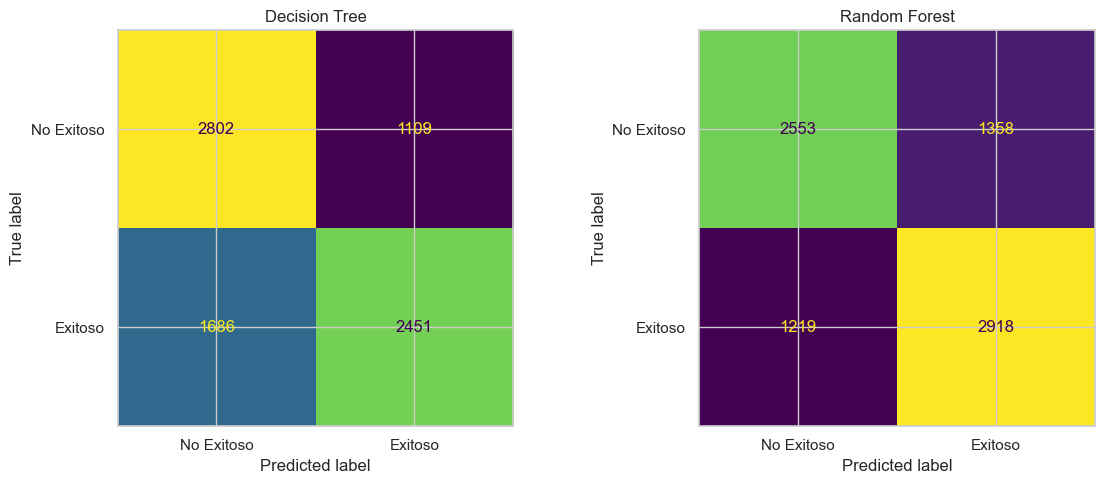

In [48]:
# Matrices de confusión
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (name, pipe) in zip(axes, [('Decision Tree', pipeline_dt), ('Random Forest', pipeline_rf)]):
    ConfusionMatrixDisplay.from_estimator(
        pipe, X_test, y_test,
        display_labels=['No Exitoso', 'Exitoso'],
        ax=ax, colorbar=False
    )
    ax.set_title(name)

plt.tight_layout()
plt.show()

**Lectura del gráfico:** Random Forest comete menos errores totales (1.358 + 1.219 = 2.577)
que Decision Tree (1.109 + 1.686 = 2.795). El Decision Tree tiende más a fallar identificando
juegos exitosos como no exitosos (1.686 falsos negativos), mientras Random Forest está más
balanceado entre ambos tipos de error.

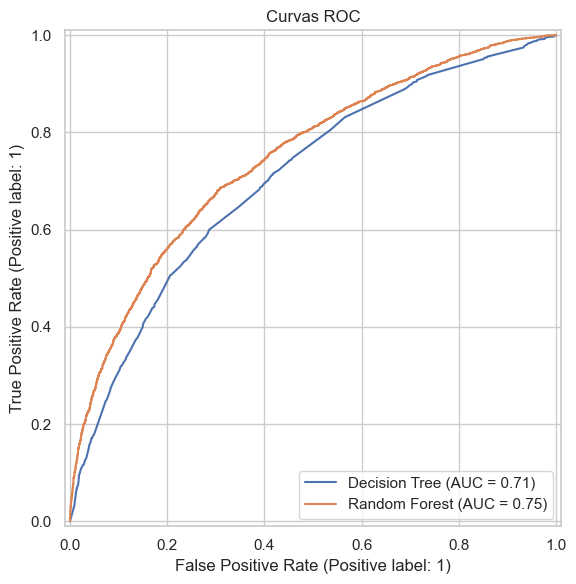

In [49]:
# Curvas ROC
fig, ax = plt.subplots(figsize=(8, 6))

for name, pipe in [('Decision Tree', pipeline_dt), ('Random Forest', pipeline_rf)]:
    RocCurveDisplay.from_estimator(pipe, X_test, y_test, ax=ax, name=name)

plt.title('Curvas ROC')
plt.tight_layout()
plt.show()

**Lectura del gráfico:** la curva de Random Forest domina a la de Decision Tree en
prácticamente todo el rango, confirmando que su mejor capacidad discriminante no depende del
umbral de clasificación elegido (0.5 por defecto), sino que es consistente en general.

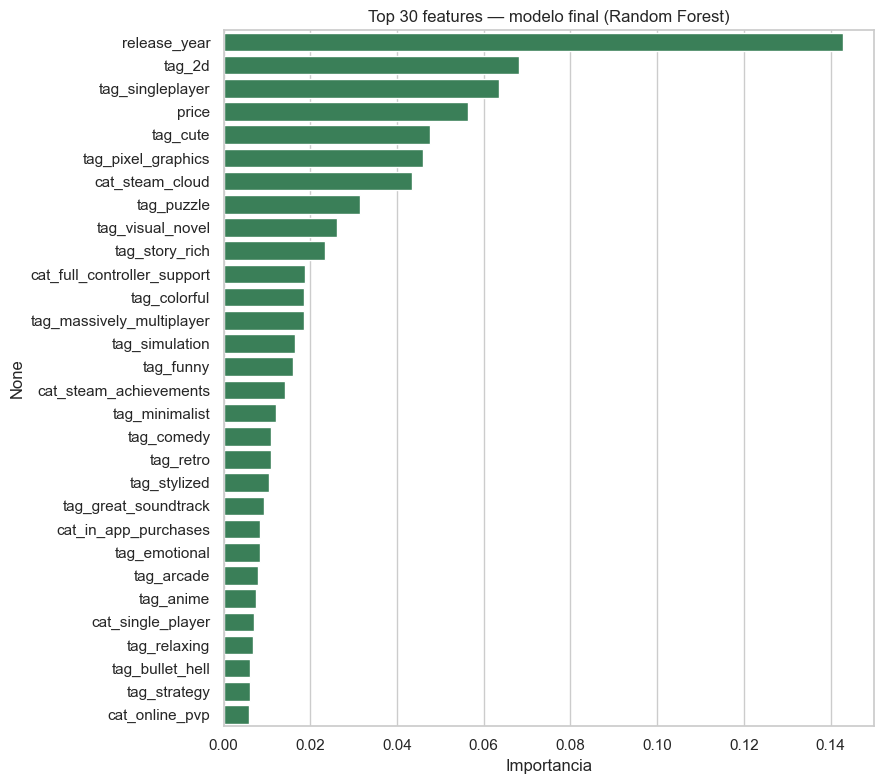

In [51]:
# Importancia de variables del modelo final (Random Forest)
rf_final_features = pipeline_rf.named_steps['selector'].selected_features_
rf_final_importances = pd.Series(
    pipeline_rf.named_steps['clf'].feature_importances_, index=rf_final_features
).sort_values(ascending=False)

plt.figure(figsize=(9, 8))
sns.barplot(x=rf_final_importances.head(30).values, y=rf_final_importances.head(30).index, color='seagreen')
plt.title('Top 30 features — modelo final (Random Forest)')
plt.xlabel('Importancia')
plt.tight_layout()
plt.show()

**Lectura del gráfico:** el ranking del modelo final coincide con el del selector de la
sección 4 (esperable, ya que ambos son Random Forest entrenados sobre el mismo train set).
`release_year` sigue siendo la variable más influyente — con la salvedad ya documentada en
la sección 3.1 sobre su correlación parcial con el sesgo de captura del dataset. Le siguen
tags que funcionan como proxy de género (`tag_2d`, `tag_singleplayer`, `tag_cute`,
`tag_pixel_graphics`, `tag_puzzle`, `tag_visual_novel`), y `price`.

### Resumen de la sección 7

| Métrica | Decision Tree | Random Forest |
|---|---|---|
| Accuracy (test) | 0.65 | **0.68** |
| F1 (clase Exitoso) | 0.64 | **0.69** |
| AUC-ROC | 0.706 | **0.747** |
| F1 CV (5-fold, train) | 0.661 ± 0.020 | **0.690 ± 0.007** |

**Random Forest se selecciona como modelo final** por superar a Decision Tree en todas las
métricas relevantes, además de ser más estable entre folds de validación cruzada. Estos
resultados, junto con sus limitaciones (en particular el rol de `release_year`), se
trasladan a las secciones de Resultados y Conclusiones del README.